CONDITIONAL WORKFLOW


In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [2]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation : str
    discriminent : float
    result : str


In [24]:
def show_eqn(state: QuadState) -> QuadState:
    equation = f'{state["a"]}x² + {state["b"]}x + {state["c"]}'

    return {'equation':equation}

def calculate_discriminent(state: QuadState) -> QuadState:
    discriminent = state['b']**2 - (4*state['a']*state['c'])

    return {'discriminent': discriminent}

def real_roots(state: QuadState) -> QuadState:
    r1 = (-state['b'] + state['discriminent']**0.5)/(2*state['a'])
    r2 = (-state['b'] - state['discriminent']**0.5)/(2*state['a'])
    result = f'the roots are {r1} and {r2}'

    return {'result': result}

def same_roots(state: QuadState) -> QuadState:
    r = (-state['b'])/2*state['a']
    result = f'the roots are {r} and {r}'

    return {'result': result}

def no_real_roots(state: QuadState) -> QuadState:
    result = f'there are no real roots !'

    return {'result': result}



In [25]:
def check_condition(state: QuadState) -> Literal["real_roots","same_roots","no_real_roots"]:
    if state["discriminent"]>0:
        return "real_roots"
    elif state["discriminent"]==0:
        return "same_roots"
    else :
        return "no_real_roots"

In [26]:
graph = StateGraph(QuadState)

#add node 
graph.add_node('show_eqn',show_eqn)
graph.add_node('calculate_discriminent',calculate_discriminent)
graph.add_node('real_roots',real_roots)
graph.add_node('same_roots',same_roots)
graph.add_node('no_real_roots',no_real_roots)


#add edge
graph.add_edge(START,'show_eqn')
graph.add_edge('show_eqn','calculate_discriminent')
graph.add_conditional_edges('calculate_discriminent',check_condition)

graph.add_edge('real_roots',END)
graph.add_edge('same_roots',END)
graph.add_edge('no_real_roots',END)



#compile and preview the workflow 
workflow = graph.compile()

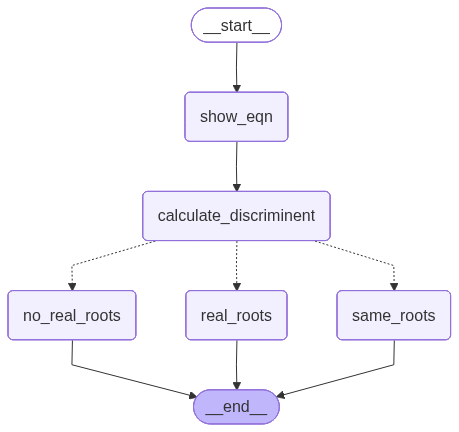

In [27]:
workflow

In [28]:
initial_state = {'a':4,
                 'b':-5,
                 'c':-4}

final_state = workflow.invoke(initial_state)

In [29]:
final_state

{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4x² + -5x + -4',
 'discriminent': 89,
 'result': 'the roots are 1.8042476415070754 and -0.5542476415070754'}